In [35]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# Load Directories and Classes

In [36]:
NUM_CLASSES = 3
CLASSES = ['LEO', 'ORI', 'SCO']
NUMPY_DIR = "quantized_weights/"

# Load Image

In [80]:
RANDOM_IMAGE = True
TRUE_LABEL  = "ORI"
IMAGE_SIZE = 64

IMAGE_INDEX = 6  # For Fixed Index
if RANDOM_IMAGE:
    IMAGE_INDEX = random.randint(0, 9) + (0 if TRUE_LABEL == "ORI" else (10 if TRUE_LABEL == "LEO" else 20))

IMAGE_PATH  = f"output_test30/{IMAGE_INDEX}_{TRUE_LABEL}_view{IMAGE_INDEX%10}_nolines_log.png"

sx_io = 1.0 / 255.0

img_load = Image.open(IMAGE_PATH).convert("L")
img_load = img_load.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)

# Convert to [1, H, W] float32 array in [0, 1] range
img_np = np.array(img_load, dtype=np.float32) / 255.0
img_np = np.expand_dims(img_np, axis=0)

x_uint8 = np.clip(np.round(img_np / sx_io), 0, 255).astype(np.uint8)

# IM2COL Implementation for Input.
Converts the uint8 image to int16 to preserve integrity. Final calculations are done in int16.

In [38]:
def im2col_uint8(x_uint8, kH=3, kW=3, pad=1, stride=1):
    C, H, W = x_uint8.shape
    out_H   = (H + 2*pad - kH) // stride + 1
    out_W   = (W + 2*pad - kW) // stride + 1

    # Sign-extend uint8 → int16 first, then pad with 0
    x_int16 = x_uint8.astype(np.int16)
    x_pad   = np.pad(x_int16, ((0,0),(pad,pad),(pad,pad)),
                     mode='constant', constant_values=0)    # 0 = black pixel, correct

    col     = np.zeros((C*kH*kW, out_H*out_W), dtype=np.int16)
    col_idx = 0
    for oh in range(out_H):
        for ow in range(out_W):
            patch           = x_pad[:, oh*stride:oh*stride+kH,
                                       ow*stride:ow*stride+kW]
            col[:, col_idx] = patch.reshape(-1)
            col_idx        += 1

    return col   # int16

# MaxPool Helper

In [39]:
def maxpool2d(x, kernel=2, stride=2):
    """
    x : [C, H, W]  any dtype
    Returns [C, H//2, W//2]
    Applied on uint8 output (after requantize), so no scale needed.
    """
    C, H, W  = x.shape
    out_H    = H // stride
    out_W    = W // stride
    out      = np.zeros((C, out_H, out_W), dtype=x.dtype)
    for oh in range(out_H):
        for ow in range(out_W):
            patch        = x[:, oh*stride:oh*stride+kernel,
                               ow*stride:ow*stride+kernel]
            out[:, oh, ow] = patch.max(axis=(1,2))
    return out

# Convolution Block
IM2COL -> Int16 Multiplication -> Dequantize -> FP32 Bias Add -> ReLU -> MaxPool -> Requantize to uint8

In [71]:
import numpy as np
import time
from pynq import Overlay, MMIO

overlay = Overlay("bitstream/design_100_wrapper.bit")

# 2. Define the BRAM Controller parameters (Must match Vivado)
BRAM_BASE_ADDRESS = 0xA0000000 
BRAM_RANGE = 0x0800 # Example: 8KB (8192 bytes)

# 3. Initialize the MMIO instance
bram_mmio = MMIO(BRAM_BASE_ADDRESS, BRAM_RANGE)

def hardware_mac_chunk(w_chunk, col_chunk):
    """
    Reads the 16x16 output block directly from BRAM and truncates it 
    to match the valid dimensions of the original input chunks.
    """
    # 1. Extract the target dimensions to know how much to truncate later
    actual_m, _ = w_chunk.shape
    _, actual_n = col_chunk.shape
    num_words = BRAM_RANGE // 8

    # Slice the array to read the entire BRAM into a numpy array instantly
    bram_data_array = bram_mmio.array[0:num_words]
        
    hw_result = bram_data_array.reshape((16, 16))
    hw_result = w_chunk.astype(np.int16) @ col_chunk.astype(np.int16)
    
    # 3. Return only the valid unpadded data
    return hw_result[:actual_m, :actual_n]

def mac_and_dequant(x_uint8, W_q, sw, b, sx_in, out_ch, out_H, out_W):
    # 1. Flatten the input using im2col and cast to int32
    col = im2col_uint8(x_uint8).astype(np.int32)
    
    M, K = W_q.shape
    _, N = col.shape
    
    # Initialize the full accumulator matrix with zeros
    acc = np.zeros((M, N), dtype=np.int32)
    
    # 2. Tile the matrix multiplication into 16x16 output blocks
    # Iterate over the rows of W_q (output channels) in steps of 16
    for i in range(0, M, 16):
        # Extract a 16 x K chunk from the weight matrix
        w_chunk = W_q[i : i+16, :]
        
        # Iterate over the columns of col (spatial dimensions) in steps of 16
        for j in range(0, N, 16):
            # Extract a K x 16 chunk from the activation matrix
            col_chunk = col[:, j : j+16]
            
            # 3. Delegate the actual computation to the separate function
            # The result is placed in the corresponding 16x16 block of the accumulator
            acc[i : i+16, j : j+16] = hardware_mac_chunk(w_chunk, col_chunk)
            
    # 4. Dequantization and Bias addition (Operating on the reconstructed full matrix)
    acc_fp = acc.astype(np.float32) * sx_in * sw[:, None]
    acc_fp = acc_fp + b[:, None]
    
    return acc_fp.reshape(out_ch, out_H, out_W)

Loading overlay...


# Load .npy data
Weights in Int8, Bias in Fp32

In [72]:
W_q1 = np.load(f"{NUMPY_DIR}/conv1_weight_int8.npy").astype(np.int32)
sw1  = np.load(f"{NUMPY_DIR}/conv1_weight_scale.npy")
b1   = np.load(f"{NUMPY_DIR}/conv1_bias_fp32.npy")

W_q2 = np.load(f"{NUMPY_DIR}/conv2_weight_int8.npy").astype(np.int32)
sw2  = np.load(f"{NUMPY_DIR}/conv2_weight_scale.npy")
b2   = np.load(f"{NUMPY_DIR}/conv2_bias_fp32.npy")

W_q3 = np.load(f"{NUMPY_DIR}/conv3_weight_int8.npy").astype(np.int32)
sw3  = np.load(f"{NUMPY_DIR}/conv3_weight_scale.npy")
b3   = np.load(f"{NUMPY_DIR}/conv3_bias_fp32.npy")

W_ql = np.load(f"{NUMPY_DIR}/linear_weight_int8.npy").astype(np.int32)
swl  = np.load(f"{NUMPY_DIR}/linear_weight_scale.npy")
bl   = np.load(f"{NUMPY_DIR}/linear_bias_fp32.npy")

# Convolution Forward Pass

## Convolution Layer 1

In [81]:
pre_relu1  = mac_and_dequant(x_uint8, W_q1, sw1, b1,
                             sx_in=sx_io, out_ch=16, out_H=64, out_W=64)
post_relu1 = np.maximum(pre_relu1, 0.0)
post_pool1 = maxpool2d(post_relu1)                         # [16, 32, 32]

sx_out1   = float(post_pool1.max()) / 255.0
x_uint8_2 = np.clip(np.round(post_pool1 / sx_out1), 0, 255).astype(np.uint8)


## Convolution Layer 2

In [82]:
pre_relu2  = mac_and_dequant(x_uint8_2, W_q2, sw2, b2,
                             sx_in=sx_out1, out_ch=32, out_H=32, out_W=32)
post_relu2 = np.maximum(pre_relu2, 0.0)
post_pool2 = maxpool2d(post_relu2)                         # [32, 16, 16]

sx_out2   = float(post_pool2.max()) / 255.0
x_uint8_3 = np.clip(np.round(post_pool2 / sx_out2), 0, 255).astype(np.uint8)

## Convolution Layer 3

In [83]:
pre_relu3  = mac_and_dequant(x_uint8_3, W_q3, sw3, b3,
                             sx_in=sx_out2, out_ch=64, out_H=16, out_W=16)
post_relu3 = np.maximum(pre_relu3, 0.0)
post_pool3 = maxpool2d(post_relu3)                         # [64, 4, 4]

## Global Average Pool and Fully Connected Layer

In [84]:
# GAP — average over spatial dims
gap_fp32 = post_pool3.mean(axis=(1, 2))                    # [64] fp32

# Quantize GAP output for Linear layer MAC
sx_gap     = float(gap_fp32.max()) / 255.0
gap_uint8  = np.clip(np.round(gap_fp32 / sx_gap), 0, 255).astype(np.uint8)  # [64] uint8
gap_int16  = gap_uint8.astype(np.int16)                                     # [64] int16

# Linear MAC
acc_lin    = W_ql @ gap_int16.astype(np.int32)             # [3] int32
logits_i   = acc_lin.astype(np.float32) * sx_gap * swl + bl

# Results

In [85]:
# Softmax on logits to find probability
e = np.exp(logits_i - logits_i.max())
probs_i = e / e.sum()
pred_idx = probs_i.argmax()

print(f"\n  [Final Predictions]")
print(f"Image path : {IMAGE_PATH}")
print(f"Logits     : {np.round(logits_i, 4)}")
print(f"Predicted  : {CLASSES[pred_idx]}")
print(f"Actual     : {TRUE_LABEL}")
print(f"Accurate   : {'Correct' if CLASSES[pred_idx] == TRUE_LABEL else 'Wrong'}")
print()

print("Prediction Probability for each Class:")
for i, cls in enumerate(CLASSES):
    print(f"{cls:<5}:{probs_i[i]*100:>7.2f}%")


  [Final Predictions]
Image path : output_test30/2_ORI_view2_nolines_log.png
Logits     : [0.1374 2.2943 0.4042]
Predicted  : ORI
Actual     : ORI
Accurate   : Correct

Prediction Probability for each Class:
LEO  :   9.13%
ORI  :  78.94%
SCO  :  11.92%


## Plot Inference Image

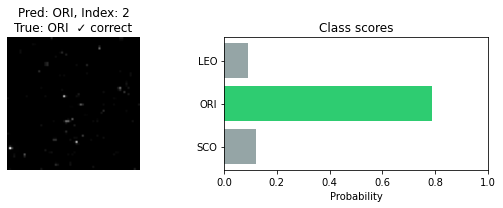

In [ ]:
if TRUE_LABEL is not None:
    assert TRUE_LABEL in CLASSES, \
        f"TRUE_LABEL '{TRUE_LABEL}' not found in CLASSES {CLASSES}"
    true_idx    = CLASSES.index(TRUE_LABEL)
    correct_str = "✓ correct" if pred_idx == true_idx else "✗ wrong"
else:
    true_idx    = None
    correct_str = ""

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
cmap = "gray"
axes[0].imshow(img_load, cmap=cmap)
title = f"Pred: {CLASSES[pred_idx]}, Index: {IMAGE_INDEX}"
if TRUE_LABEL is not None:
    title += f"\nTrue: {TRUE_LABEL}  {correct_str}"
axes[0].set_title(title, fontsize=12); axes[0].axis("off")
colors = [
    "#2ecc71" if i == pred_idx and (true_idx is None or pred_idx == true_idx)
    else "#e74c3c" if i == pred_idx and pred_idx != true_idx
    else "#3498db" if i == true_idx
    else "#95a5a6"
    for i in range(NUM_CLASSES)
]
axes[1].barh(CLASSES, probs_i, color=colors)
axes[1].set_xlim(0, 1); axes[1].set_xlabel("Probability")
axes[1].set_title("Class scores"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()